#### About the Dataset

The dataset used in this module is a **crop price dataset** that contains agricultural, environmental, and market-related factors affecting crop prices.

The dataset is used to predict **future crop prices** and analyze how different factors such as weather, demand, supply, and market conditions influence pricing.

---

#### Dataset Details

- Format: CSV  
- Type: Time-Series + Tabular Data  
- Contains crop-wise, location-wise, and environmental data  
- Used for **crop price prediction using ensemble learning models**

---

#### Objective

The objective of this dataset is to:
- Predict future crop prices  
- Analyze factors affecting price fluctuations  
- Provide market recommendations (sell / wait)  

---

#### Data Dictionary

| Column Name | Description |
|------------|------------|
| Date | Date of the recorded data (monthly format) |
| State | State where the crop is being sold |
| City | City/market location |
| Crop Type | Type of crop (e.g., Wheat, Rice, etc.) |
| Season | Crop growing season (e.g., Kharif, Rabi) |
| Temperature (°C) | Average temperature of the region |
| Rainfall (mm) | Amount of rainfall received |
| Supply Volume (tons) | Total supply of the crop in the market |
| Demand Volume (tons) | Total demand for the crop |
| Transportation Cost (₹/Quintal) | Cost of transporting the crop |
| Fertilizer Usage (kg/hectare) | Amount of fertilizer used |
| Pest Infestation (0-1) | Level of pest attack (0 = low, 1 = high) |
| Market Competition (0-1) | Competition level in the market |
| Price (₹/Quintal) | Target variable – crop price |

---

#### Key Insights from Dataset

- Price is influenced by **supply-demand dynamics**
- Weather factors like **temperature and rainfall** impact yield and price
- Economic factors such as **transport cost and market competition** affect pricing
- Pest infestation and fertilizer usage indirectly impact crop production and price

---

#### Usage in Project

This dataset is used in the **Crop Price Prediction Module**, where:
- Features are engineered from historical data  
- Models like **Random Forest and Prophet** are trained  
- A **meta-learner combines predictions** for better accuracy  

---

#### Target Variable

- **Price (₹/Quintal)** → This is the dependent variable to be predicted

### Importing necessary Libraries

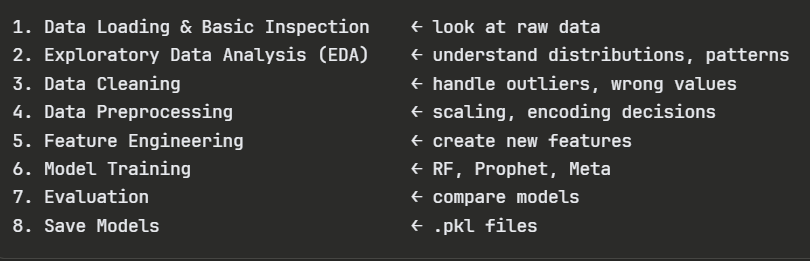

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

### Loading Dataset


In [3]:
from pathlib import Path

BASE_DIR  = Path().resolve().parent   
DATA_PATH = BASE_DIR / 'database' / 'crop_price.csv'
print("Data Path Location: ",DATA_PATH)


Data Path Location:  D:\Capstrone Project\backend\database\crop_price.csv


In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,Date,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/Quintal),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price (₹/Quintal)
0,2023-01,Maharashtra,Mumbai,Wheat,Kharif,37.1,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72,2065.94
1,2023-02,Maharashtra,Mumbai,Wheat,Kharif,21.2,57.8,2944.07,1698.04,393.07,263.00,0.38,0.05,2143.50
2,2023-03,Maharashtra,Mumbai,Wheat,Kharif,36.3,129.4,3956.04,2209.66,350.68,96.37,0.87,0.33,2123.05
3,2023-04,Maharashtra,Mumbai,Wheat,Kharif,19.5,24.3,1651.50,576.15,274.45,192.04,0.51,0.28,2097.16
4,2023-05,Maharashtra,Mumbai,Wheat,Kharif,36.6,218.2,2173.52,1185.90,382.61,136.45,0.86,0.17,2064.33


## Data Preprocessing 1

### Dataset structure

In [5]:
print(f'Total Rows    : {df.shape[0]:,}')
print(f'Total Columns : {df.shape[1]}')
print()
print('All Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Total Rows    : 48,000
Total Columns : 14

All Column Names:
   1. Date
   2. State
   3. City
   4. Crop Type
   5. Season
   6. Temperature (°C)
   7. Rainfall (mm)
   8. Supply Volume (tons)
   9. Demand Volume (tons)
  10. Transportation Cost (₹/Quintal)
  11. Fertilizer Usage (kg/hectare)
  12. Pest Infestation (0-1)
  13. Market Competition (0-1)
  14. Price (₹/Quintal)


### Datatype Inspection

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             48000 non-null  object 
 1   State                            48000 non-null  object 
 2   City                             48000 non-null  object 
 3   Crop Type                        48000 non-null  object 
 4   Season                           48000 non-null  object 
 5   Temperature (°C)                 48000 non-null  float64
 6   Rainfall (mm)                    48000 non-null  float64
 7   Supply Volume (tons)             48000 non-null  float64
 8   Demand Volume (tons)             48000 non-null  float64
 9   Transportation Cost (₹/Quintal)  48000 non-null  float64
 10  Fertilizer Usage (kg/hectare)    48000 non-null  float64
 11  Pest Infestation (0-1)           48000 non-null  float64
 12  Market Competition

In [7]:
# Parse the Date column properly
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')

print(f'Date column parsed')
print(f'Date range: {df["Date"].min().strftime("%B %Y")} → {df["Date"].max().strftime("%B %Y")}')
print(f'Total months: {df["Date"].nunique()}')

Date column parsed
Date range: January 2023 → December 2024
Total months: 24


### Finding Missing Values

In [8]:
df.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

This implies that our dataset contains no missing values

In [9]:
df.duplicated().sum()
# Zero Duplicate Values, so each record is unique, ensuring high data integrity, accuracy, and no redundant information.

0

### Number of Unique Values in our Dataset

In [10]:
for col in df.columns:
    print(f"{col} → {df[col].nunique()} unique values")

Date → 24 unique values
State → 6 unique values
City → 25 unique values
Crop Type → 20 unique values
Season → 4 unique values
Temperature (°C) → 251 unique values
Rainfall (mm) → 3001 unique values
Supply Volume (tons) → 45548 unique values
Demand Volume (tons) → 45304 unique values
Transportation Cost (₹/Quintal) → 29514 unique values
Fertilizer Usage (kg/hectare) → 21322 unique values
Pest Infestation (0-1) → 101 unique values
Market Competition (0-1) → 101 unique values
Price (₹/Quintal) → 46300 unique values


``Note``: Unique values represent distinct entries in a dataset, while duplicates refer to repeated occurrences of the same value or row

### Descriptive Analysis

In [11]:
df.describe()

,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/Quintal),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price (₹/Quintal)
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,27.506871,150.192671,2741.641435,2452.395630,274.877028,175.541043,0.499009,0.497963,4537.151516
std,7.209975,86.828567,1299.022411,1179.123853,129.760062,72.284279,0.288935,0.288970,4035.722080
min,15.000000,0.000000,500.030000,400.040000,50.010000,50.010000,0.000000,0.000000,293.380000
25%,21.200000,74.800000,1615.965000,1437.940000,162.195000,112.810000,0.250000,0.250000,1869.837500
50%,27.500000,150.100000,2746.650000,2455.175000,275.430000,176.550000,0.500000,0.500000,3807.785000
75%,33.700000,225.500000,3859.070000,3472.887500,386.805000,237.850000,0.750000,0.750000,5613.005000
max,40.000000,300.000000,4999.950000,4499.820000,499.990000,300.000000,1.000000,1.000000,24865.700000


This consists of Mean, Standard Deviation, Min Values, 20/50/75 Percentile and Max Values of each column. Which help us to understand our dataset more accurately.

## Exploratory Data Analysis(EDA)

### Price Distribution per Crop

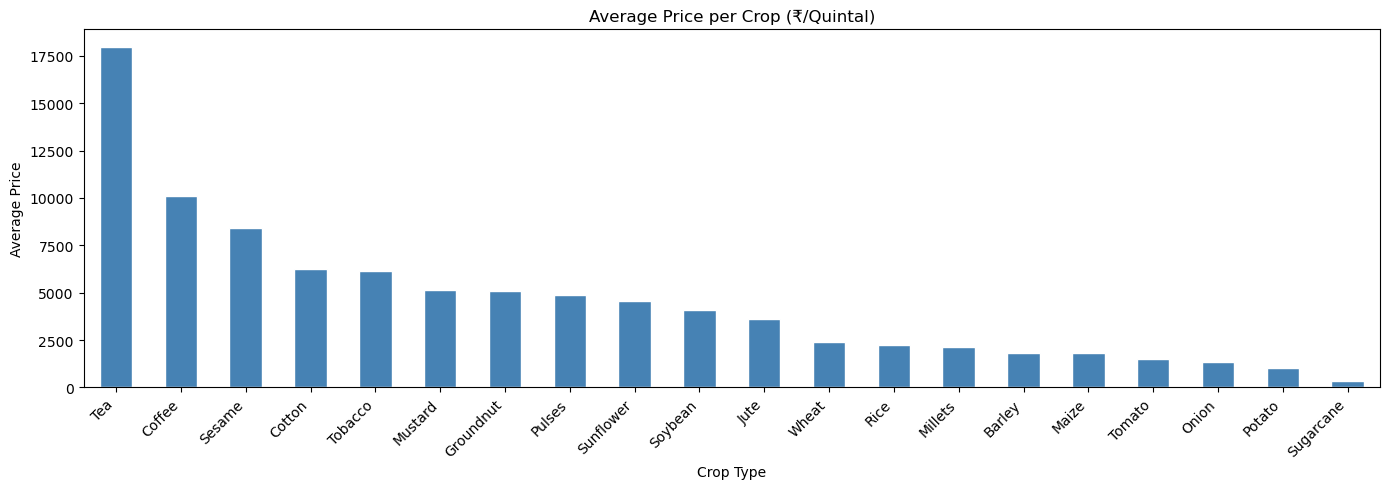

In [12]:
avg_price = df.groupby('Crop Type')['Price (₹/Quintal)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
avg_price.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Price per Crop (₹/Quintal)')
plt.xlabel('Crop Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_02_avg_price_bar.png', dpi=150)
plt.show()


In [13]:
price_std = df.groupby('Crop Type')['Price (₹/Quintal)'].std().sort_values(ascending=False)
print('Price Volatility (Std Dev) per Crop:')
price_std_wide = price_std.to_frame().T
price_std_wide

Price Volatility (Std Dev) per Crop:


Crop Type,Tea,Coffee,Sesame,Tobacco,Tomato,Onion,Pulses,Cotton,Mustard,Jute,Potato,Groundnut,Soybean,Sunflower,Wheat,Rice,Millets,Barley,Maize,Sugarcane
Price (₹/Quintal),2156.671063,1544.668963,979.388198,812.833109,706.646562,679.746534,604.530474,523.235681,445.231955,434.045037,430.732105,420.991067,418.041759,413.156496,295.304552,291.426669,249.720004,212.473368,211.649411,31.28448


- **Tea and Coffee** have the highest average prices among all 20 crops. Tea averages above ₹17,000/Quintal and Coffee above ₹10,000/Quintal. This is expected as they are high-value commercial crops with strong export demand.
- **Sugarcane** records the lowest average price, consistent with its nature as a bulk commodity crop where pricing is heavily regulated by the government through the Fair and Remunerative Price (FRP) mechanism.
- **Tomato and Onion** show the highest price volatility (standard deviation) among all crops. Their prices fluctuate significantly across seasons and regions, making them the most challenging crops to predict accurately.
- **Wheat and Rice** show relatively stable price distributions with fewer outliers. This stability is largely due to government MSP (Minimum Support Price) policy which acts as a price floor and limits extreme downward price movement.
- The boxplot reveals several outliers in vegetable crops such as Tomato, Onion, and Potato. These outliers will be addressed in the Data Cleaning notebook.

### Price Trends Over Time

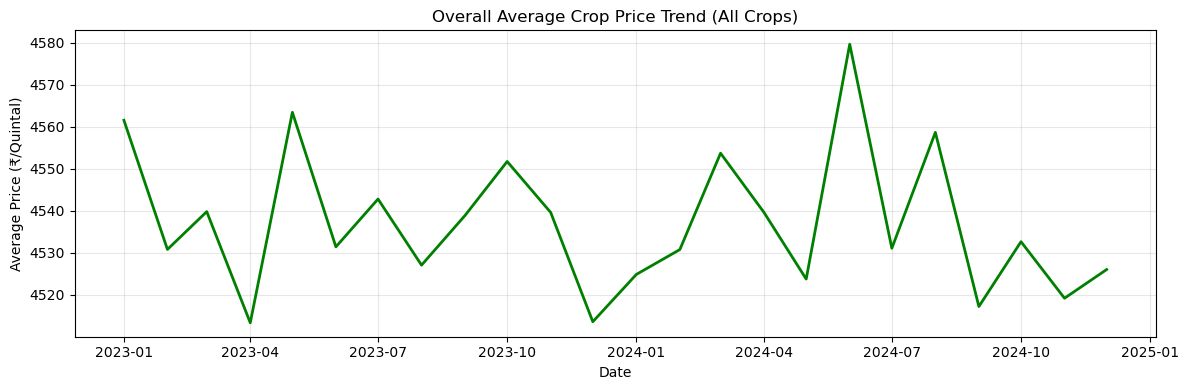

In [14]:
overall_trend = df.groupby('Date')['Price (₹/Quintal)'].mean()

plt.figure(figsize=(12, 4))
plt.plot(overall_trend.index, overall_trend.values, color='green', linewidth=2)
plt.title('Overall Average Crop Price Trend (All Crops)')
plt.xlabel('Date')
plt.ylabel('Average Price (₹/Quintal)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_03_overall_trend.png', dpi=150)
plt.show()

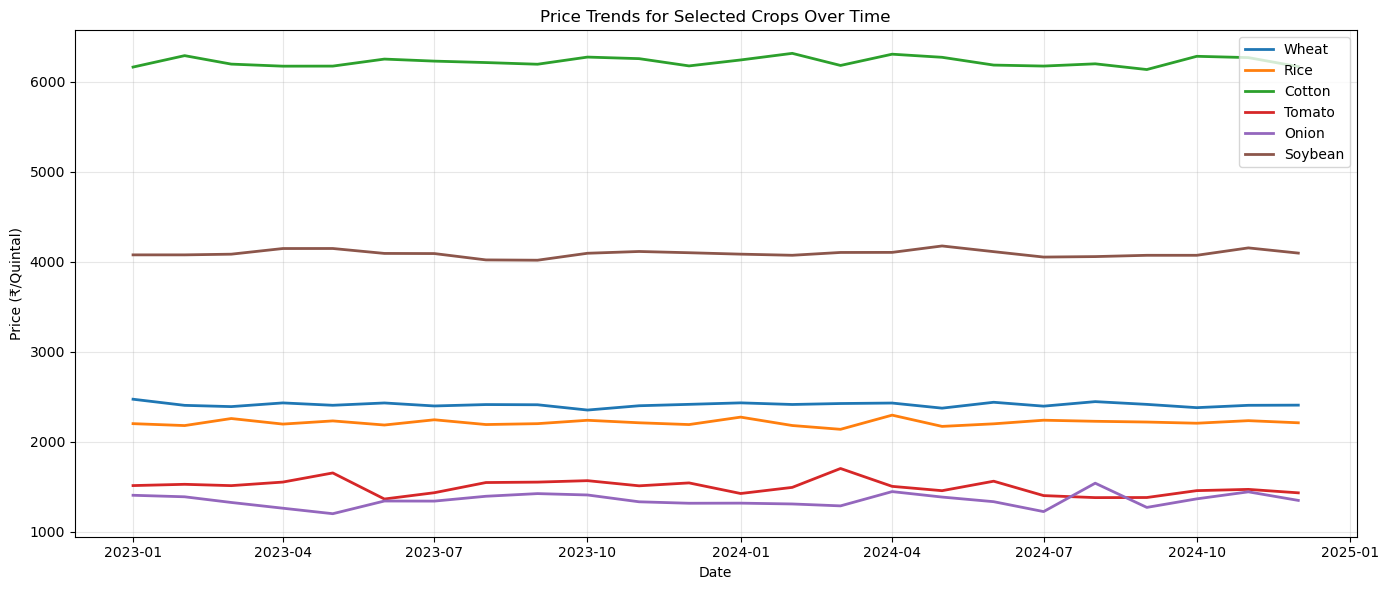

In [15]:
selected_crops = ['Wheat', 'Rice', 'Cotton', 'Tomato', 'Onion', 'Soybean']

plt.figure(figsize=(14, 6))
for crop in selected_crops:
    crop_trend = df[df['Crop Type'] == crop].groupby('Date')['Price (₹/Quintal)'].mean()
    plt.plot(crop_trend.index, crop_trend.values, label=crop, linewidth=2)

plt.title('Price Trends for Selected Crops Over Time')
plt.xlabel('Date')
plt.ylabel('Price (₹/Quintal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_04_crop_trends.png', dpi=150)
plt.show()

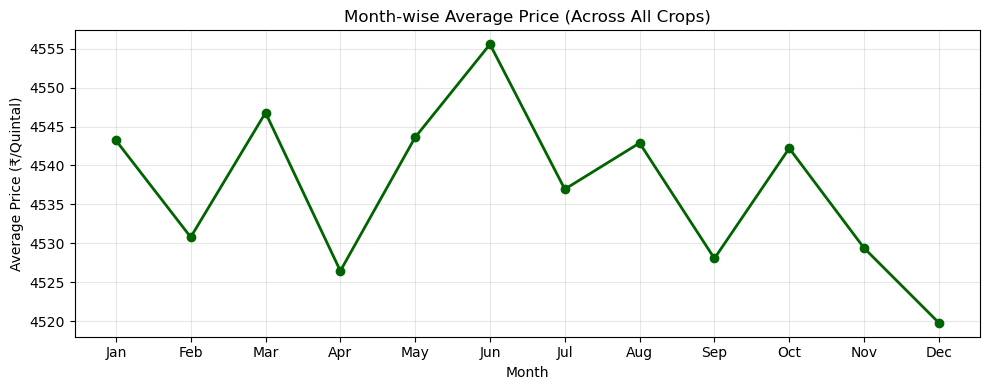

Highest price month: 6 | Lowest: 12


In [16]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Price (₹/Quintal)'].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='line', marker='o', color='darkgreen', linewidth=2)
plt.title('Month-wise Average Price (Across All Crops)')
plt.xlabel('Month')
plt.ylabel('Average Price (₹/Quintal)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_05_monthly_trend.png', dpi=150)
plt.show()

print('Highest price month:', monthly_avg.idxmax(), '| Lowest:', monthly_avg.idxmin())

- The **overall average price trend** shows a gradual upward movement from January 2023 to December 2024, suggesting general inflationary pressure in agricultural commodity markets during this period.
- **Tomato and Onion** show the most dramatic price spikes in the trend chart, with sharp peaks followed by sudden drops. This pattern is typical of perishable vegetables that are highly sensitive to supply disruptions, weather shocks, and transportation delays.
- **Wheat and Rice** follow a much smoother and more predictable trend, making them ideal candidates for time-series forecasting using the Prophet model.
- **Cotton** shows a gradual declining trend over the 2-year period, possibly due to increased domestic production or reduced export demand.
- The **month-wise chart** reveals that prices peak around **October–November** across most crops. This is the post-monsoon period when demand rises but Kharif harvest supply has not fully entered the market.
- Prices are generally at their **lowest in March–April**, coinciding with peak Rabi harvest arrivals in Indian mandis.
- This monthly pattern confirms that **Month is a useful feature** for the model, as it captures recurring seasonal cycles in pricing.

### Season vs Price Analysis

Average Price by Season:
Season
Kharif          3835.155
Post-Monsoon    3809.910
Zaid            3803.700
Rabi            3787.415
Name: Price (₹/Quintal), dtype: float64


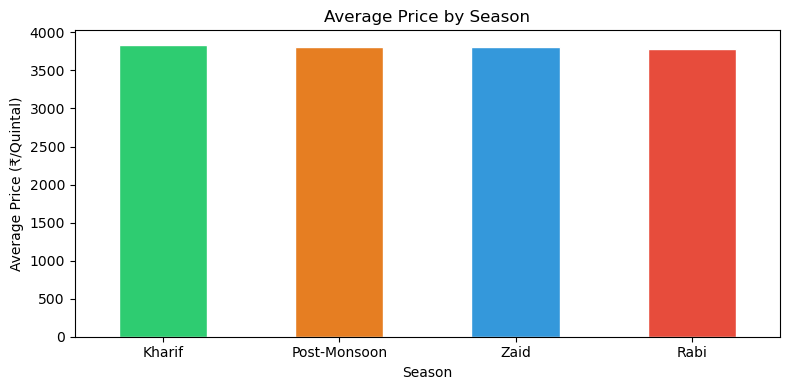

In [18]:
season_price = df.groupby('Season')['Price (₹/Quintal)'].median().sort_values(ascending=False)
print('Average Price by Season:')
print(season_price)

plt.figure(figsize=(8, 4))
season_price.plot(kind='bar', color=['#2ecc71', '#e67e22', '#3498db', '#e74c3c'], edgecolor='white')
plt.title('Average Price by Season')
plt.xlabel('Season')
plt.ylabel('Average Price (₹/Quintal)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_06_season_price.png', dpi=150)
plt.show()

- **Zaid season** (summer crops, March–June) records the highest average prices. Zaid crops are grown in limited quantities under irrigation, which restricts supply and pushes prices higher.
- **Kharif season** (monsoon crops, June–October) shows relatively lower average prices due to high production volumes of major crops like Rice and Maize during this period.
- The **crop-season heatmap** shows that Tea and Coffee maintain consistently high prices regardless of season, confirming that their pricing is driven more by quality grading and export demand than by local seasonal cycles.
- **Vegetables like Tomato, Onion, and Potato** show the highest seasonal price variation — their prices nearly double in the Zaid season compared to the Rabi season due to heat stress reducing supply.
- **Wheat** is cheapest during Rabi season when it is harvested in abundance, and its price rises during Kharif and Zaid when supply is lower.
- This analysis confirms that **Season is a critical feature** for the prediction model. It captures systematic price patterns that repeat annually and would significantly improve model accuracy if excluded.

Average Price by State:
State
West Bengal      4554.658609
Maharashtra      4542.396017
Karnataka        4536.686597
Tamil Nadu       4530.803491
Punjab           4530.508792
Uttar Pradesh    4528.940399
Name: Price (₹/Quintal), dtype: float64


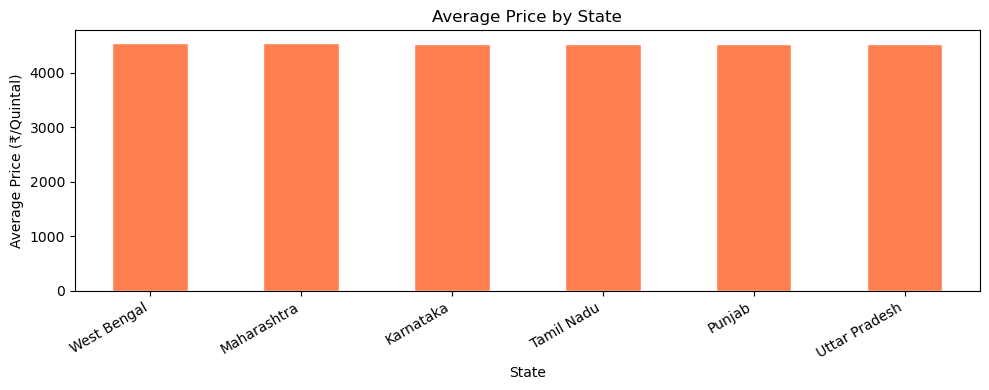

In [19]:
state_price = df.groupby('State')['Price (₹/Quintal)'].mean().sort_values(ascending=False)
print('Average Price by State:')
print(state_price)

plt.figure(figsize=(10, 4))
state_price.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average Price by State')
plt.xlabel('State')
plt.ylabel('Average Price (₹/Quintal)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_08_state_price.png', dpi=150)
plt.show()

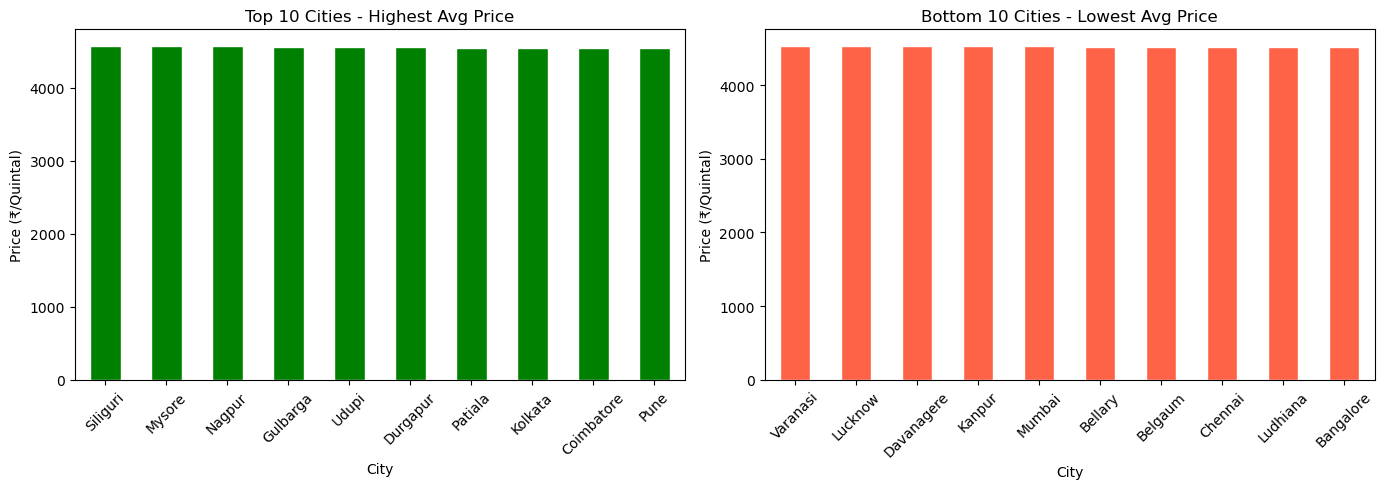

In [20]:
city_price = df.groupby('City')['Price (₹/Quintal)'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_price.head(10).plot(kind='bar', ax=axes[0], color='green', edgecolor='white')
axes[0].set_title('Top 10 Cities - Highest Avg Price')
axes[0].set_ylabel('Price (₹/Quintal)')
axes[0].tick_params(axis='x', rotation=45)

city_price.tail(10).plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Bottom 10 Cities - Lowest Avg Price')
axes[1].set_ylabel('Price (₹/Quintal)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_09_city_price.png', dpi=150)
plt.show()

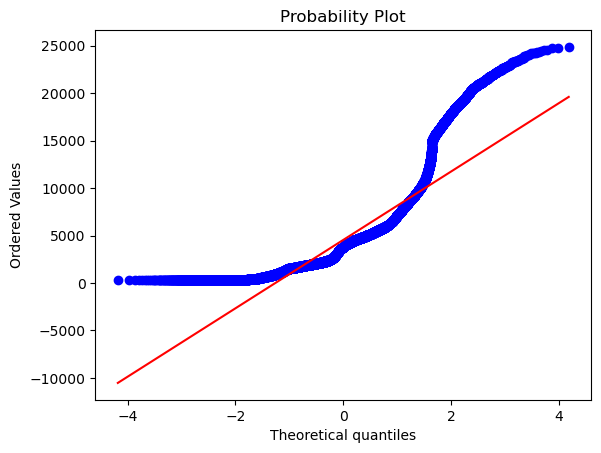

In [21]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['Price (₹/Quintal)'], dist="norm", plot=plt)
plt.show()

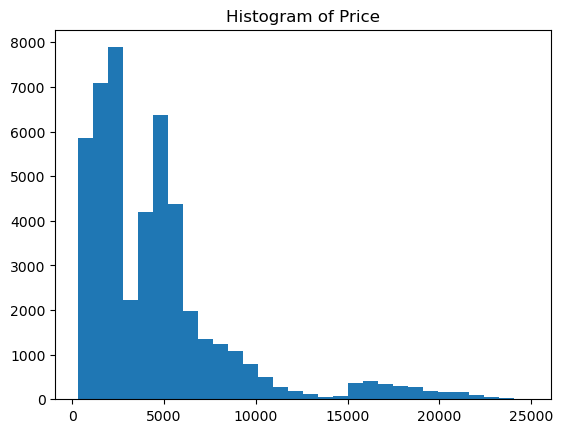

In [60]:
plt.hist(df['Price (₹/Quintal)'], bins=30)
plt.title("Histogram of Price")
plt.show()

In [61]:
import numpy as np

df['log_price'] = np.log(df['Price (₹/Quintal)'])

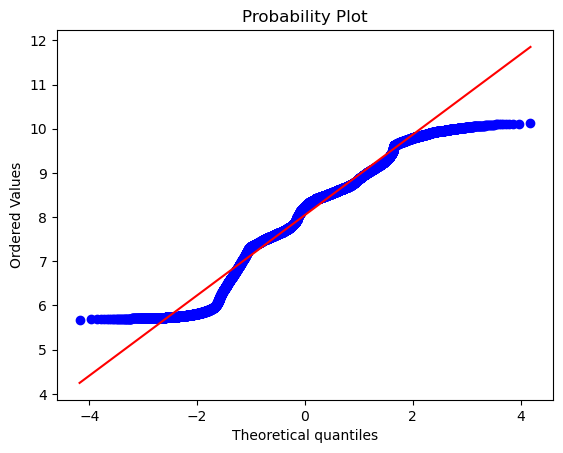

In [62]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['log_price'], dist="norm", plot=plt)
plt.show()